# Train a tram forecast and create a November–December submission

This notebook trains and validates a model, then can refit it on January–October
and write forecasts for all 61 days of November and December. A 61-day validation
run measures WAPE on the observed September–October holdout. The November–December
actual labels are withheld, so the final submission itself cannot be scored locally.

Run cells in order. Preparation needs only the hourly boarding label CSVs. No data,
weights, or executed outputs are embedded in this notebook.

Install the package with the `notebook` extra, select that environment as your
Jupyter kernel, and restart the kernel after changing PyTorch. See the repository
README for installation commands.


In [1]:
from pathlib import Path
from datetime import date, timedelta

import numpy as np
import torch
import matplotlib.pyplot as plt

from tram_forecast.data import Boardings, ForecastDataset
from tram_forecast.train import train, load_model
from tram_forecast.predict import predict, fixed_forecast

ROOT = Path.cwd().parent


## Configure the run

`BATCH_SIZE` counts contexts. Each context has up to `FORECAST_DAYS` targets;
near the fitting boundary the group is shorter. Gradients are weighted by the
number of requested days.

Use `FORECAST_DAYS = 61` to validate across September 1–October 31 and to prepare
a model for the full November–December horizon. Validation freezes HISTORY_DAYS at
September 1; it does not update HISTORY_DAYS with observed days during the 61-day holdout.
Choose a new `RUN_NAME` for each experiment.


In [2]:
FORECAST_DAYS = 14
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
EPOCHS = 50
BATCH_SIZE = 60
HISTORY_DAYS = 14
RUN_NAME = f'cnn_{FORECAST_DAYS}days_v7'
LABELS = [ROOT / 'dataset/labels/labels_day_train.csv', ROOT / 'dataset/labels/labels_day_test.csv']
OUTPUT = ROOT / 'outputs' / f'{RUN_NAME}.pt'


## Prepare or reuse the validation artifact

`Boardings.load` reads a single CSV, but the boarding HISTORY_DAYS ships as two files
(`labels_day_train.csv` covering the earlier period and `labels_day_test.csv`
covering the September–October actuals). `load_boardings` below loads each file
into the same date range and merges them so both periods end up in one store.

For a 61-day horizon the validation report uses observed September–October
labels. Preparation may take time on the full dataset. Use complete source
CSVs; `Boardings.load` rejects truncated or malformed rows.


In [3]:
def load_boardings(paths, **kwargs):
    """Merge several label CSVs (e.g. train + test) into a single Boardings store."""
    boardings = None
    for path in paths:
        part = Boardings.load(path, **kwargs)
        if boardings is None:
            boardings = part
        else:
            mask = part.counts != 0
            boardings.counts[mask] = part.counts[mask]
    return boardings


In [4]:
train_boardings = load_boardings(LABELS, end=date(2025, 9, 1))
val_boardings = load_boardings(LABELS, start=date(2025, 8, 11), end=date(2025, 11, 1)) 
print('Training contexts:', len(ForecastDataset(train_boardings, FORECAST_DAYS, HISTORY_DAYS)))
print('Validataion contexts:', len(ForecastDataset(val_boardings, FORECAST_DAYS, HISTORY_DAYS)))

Training contexts: 1944
Validataion contexts: 495


## Train

This cell runs training and prints one summary per epoch. Validation uses the
same fixed context at every epoch. Whenever validation WAPE improves, the model
and its scale are saved to `OUTPUT`; the returned path is the checkpoint with
the lowest validation WAPE seen during the run.


In [5]:
best_checkpoint = train(
    train_boardings, val_boardings,
    forecast_days=FORECAST_DAYS, history_days=HISTORY_DAYS, 
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    lr=8e-4,
    weight_decay=0.,
    device=DEVICE, output=OUTPUT,
)
print('Selected checkpoint:', best_checkpoint)


Epoch 1/50:   0%|          | 0/33 [00:00<?, ?it/s]

/home/unicorn/trans_predicting/.venv/lib64/python3.14/site-packages/torch/nn/modules/conv.py:380: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/Convolution.cpp:1104.)
  return F.conv1d(
/home/unicorn/trans_predicting/src/tram_forecast/train.py:59: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:820.)
  total_loss += float(loss) * target.shape[0]


Epoch 1/50 | MAE=440.4123 | val MAE=321.9733 | val WAPE=0.3322


Epoch 2/50:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 2/50 | MAE=273.9294 | val MAE=233.9148 | val WAPE=0.2399


...

Epoch 17/50 | MAE=117.8832 | val MAE=135.1392 | val WAPE=0.1381


Epoch 18/50:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 18/50 | MAE=120.3412 | val MAE=120.0351 | val WAPE=0.1227


Epoch 19/50:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 19/50 | MAE=112.3688 | val MAE=128.6972 | val WAPE=0.1322
Selected checkpoint: /home/unicorn/trans_predicting/outputs/cnn_14days_v7.pt


## Evaluate the best checkpoint on September–October

With `FORECAST_DAYS = 61`, these metrics compare the forecast from a fixed
September 1 cutoff against observed September–October labels. This is the
local holdout score used to select a model; it is not the eventual
November–December competition score.


In [6]:
model = load_model(best_checkpoint, device=DEVICE)
prediction = fixed_forecast(model, val_boardings, cutoff=date(2025, 9, 1), days=FORECAST_DAYS, history_days=HISTORY_DAYS)
actual = np.stack(
    [val_boardings.target(r, date(2025, 9, 1) + timedelta(days=d)) for r in val_boardings.routes for d in range(FORECAST_DAYS)]
).reshape(len(val_boardings.routes), FORECAST_DAYS, 24)
wape = float(np.abs(actual - prediction).sum() / actual.sum())
print('WAPE:', wape)


WAPE: 0.1293167620897293


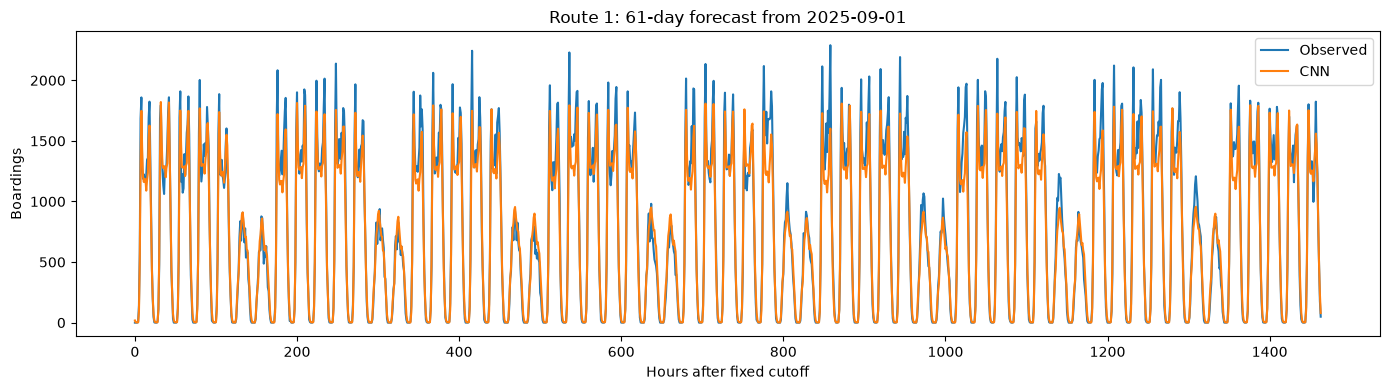

In [7]:
PLOT_DAYS = 61
CUTOFF = date(2025, 9, 1)

ROUTE_TO_PLOT = val_boardings.routes[0]
route_index = val_boardings.routes.index(ROUTE_TO_PLOT)

prediction = fixed_forecast(
    model, val_boardings,
    cutoff=CUTOFF,
    days=PLOT_DAYS,
    history_days=HISTORY_DAYS,
)

actual_route = np.concatenate([
    val_boardings.target(ROUTE_TO_PLOT, CUTOFF + timedelta(days=d))
    for d in range(PLOT_DAYS)
])
hours = np.arange(PLOT_DAYS * 24)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(hours, actual_route, label="Observed")
ax.plot(hours, prediction[route_index].reshape(-1), label="CNN")
ax.set(
    title=f"Route {ROUTE_TO_PLOT}: {PLOT_DAYS}-day forecast from {CUTOFF}",
    xlabel="Hours after fixed cutoff",
    ylabel="Boardings",
)
ax.legend()
fig.tight_layout()
plt.show()

## Export an un-refit November–December forecast

Before refitting, run the model selected above directly at the November 1
cutoff. `val_boardings` already has the 21 days of HISTORY_DAYS (October 11–31)
needed for that cutoff, so this is a quick sanity export — not the final
submission — useful for comparing against the refit result below.


In [8]:
SUBMISSION = ROOT / 'outputs' / 'cnn_nov_dec_submission_un_ref.csv'
written = predict(model, val_boardings, ROOT / 'dataset/test_submission.csv', SUBMISSION, cutoff=date(2025, 11, 1), days=61, history_days=HISTORY_DAYS)
print('Submission:', written)


Submission: 14640


## Refit on January–October and export November–December forecasts

After reviewing the September–October validation WAPE, run these cells to train
fresh weights on all January–October observations and create the full 14,640-row
submission. The refit reuses the same `EPOCHS`/`BATCH_SIZE` configuration as the
validation run above and trains from scratch — it does not reuse the validation
run's weights.

There is no held-out slice for this run: November–December labels are withheld,
so `train` is given the same boardings for both its train and validation
arguments purely so it has something to print each epoch. Make sure the
boarding label CSVs cover January–October before running this cell; the final
export cannot be scored locally, so the validation metrics above remain the
best available estimate.


In [9]:
final_boardings = load_boardings(LABELS, end=date(2025, 10, 1))
final_boardings_val = load_boardings(LABELS, start=date(2025, 10, 1)-timedelta(days=HISTORY_DAYS), end=date(2025, 11, 1))
final_checkpoint = train(
    final_boardings, final_boardings_val,
    forecast_days=FORECAST_DAYS, history_days=HISTORY_DAYS, epochs=EPOCHS, batch_size=BATCH_SIZE,
    device=DEVICE, output=ROOT / 'outputs' / f'{RUN_NAME}_final.pt',
)
print('Selected checkpoint:', best_checkpoint)
model = load_model(final_checkpoint, device=DEVICE)

Epoch 1/50:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 1/50 | MAE=471.5293 | val MAE=266.3758 | val WAPE=0.2655


Epoch 2/50:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 2/50 | MAE=257.3198 | val MAE=251.6401 | val WAPE=0.2568


Epoch 3/50:   0%|          | 0/37 [00:00<?, ?it/s]

...

Epoch 31/50 | MAE=95.6069 | val MAE=100.0674 | val WAPE=0.1011


Epoch 32/50:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 32/50 | MAE=95.4846 | val MAE=95.8535 | val WAPE=0.0982


Epoch 33/50:   0%|          | 0/37 [00:00<?, ?it/s]

Epoch 33/50 | MAE=93.8412 | val MAE=95.0449 | val WAPE=0.0974
Selected checkpoint: /home/unicorn/trans_predicting/outputs/cnn_14days_v7.pt


In [10]:
SUBMISSION = ROOT / 'outputs' / 'cnn_nov_dec_submission1.csv'
written = predict(model, val_boardings, ROOT / 'dataset/test_submission.csv', SUBMISSION, cutoff=date(2025, 11, 1), days=61, history_days=HISTORY_DAYS)
print('Submission:', written)

Submission: 14640


## Next steps

- Use the lowest validation WAPE checkpoint (`best_checkpoint` above) to decide
  whether the model is worth refitting.
- The final November–December actual labels are withheld. The final forecast CSV can
  be submitted, but its WAPE cannot be calculated locally without those actuals.

This notebook calls the package's `train`, `predict`, and `load_model` functions
directly, so checkpointing and evaluation behavior stay consistent with the rest
of the package.
